In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
file_path = "APMS23-24-Posttraumatic-Stress-Disorder-data-tables.xlsx"

In [4]:
workbook = pd.ExcelFile(file_path)

### Read Table 3.5 (Debt Table)

In [5]:
# Read the next NHS table without assuming where its headers are
table_3_5 = pd.read_excel(
    file_path,
    sheet_name="Table 3.5",
    header=None
)

# Display the first 25 rows to understand its structure
table_3_5.head(25)

,0,1,2
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,Table 3.5: Screening positive for probable PTS...,NaN,NaN
4,All adults,NaN,NaN
5,Trauma1 \nScreen p...,Problem debt3,NaN
6,NaN,Yes,No
7,NaN,%,%
8,Age-standardised4,NaN,NaN
9,Men,NaN,NaN


In [6]:
debt_estimates = table_3_5.iloc[9:20, 0:3].copy()

Algorithm note - Extracting debt estimates (Table 3.5)

We use `.iloc[9:20, 0:3].copy()` to extract the debt estimate section from the original NHS table.

- `table_3_5` = original NHS debt table.
- `.iloc[9:20, 0:3]` = selects rows 9–19 and columns 0–2.
- `.copy()` = creates an independent DataFrame without modifying the original.
- `debt_estimates` = stores the extracted data.

Why? To isolate the relevant debt observations before cleaning.

Conclusion: The debt estimate section has been extracted and is ready for cleaning and restructuring.

In [7]:
# Reconstruct gender labels from the original NHS table
gender_labels = []
current_gender = None

for value in debt_estimates.iloc[:, 0]:

    if value in ["Men", "Women", "All adults5"]:
        current_gender = value

    gender_labels.append(current_gender)

# Add the reconstructed labels to our table
debt_estimates["gender"] = gender_labels

debt_estimates

,0,1,2,gender
9,Men,NaN,NaN,Men
10,Trauma experienced,48.115202,30.587807,Men
11,PTSD screen positive,14.388422,4.056719,Men
12,NaN,NaN,NaN,Men
13,Women,NaN,NaN,Women
14,Trauma experienced,52.225426,35.797899,Women
15,PTSD screen positive,17.806125,4.869006,Women
16,NaN,NaN,NaN,Women
17,All adults5,NaN,NaN,All adults5
18,Trauma experienced,50.470283,33.422477,All adults5


Algorithm note - Reconstructing gender labels (Table 3.5)

We use a `for` loop and conditional logic to assign the correct gender to each observation.

- `gender_labels = []` = creates an empty list to store gender labels.
- `current_gender = None` = initialises the current gender as unknown.
- `for value in debt_estimates.iloc[:, 0]` = loops through every value in the first column.
- `if value in [...]` = checks whether the value is Men, Women, or All adults5.
- `current_gender = value` = updates the gender when a new group label is found.
- `.append(current_gender)` = adds the current gender to the list for every row.
- `debt_estimates["gender"] = gender_labels` = creates a new gender column.

Algorithm concepts:
- Iteration: visits each row sequentially.
- Conditional logic: identifies gender headings.
- State tracking: remembers the most recent gender.
- Accumulation: collects labels in a list.
- Time complexity: O(n).

Why? The original NHS table displays gender headings only once per group. We need to assign the correct gender to every observation.

In [8]:
# Keep only the two measures we want to analyse
observation_measures = [
    "Trauma experienced",
    "PTSD screen positive"
]

debt_estimates = debt_estimates[
    debt_estimates[0].isin(observation_measures)
].copy()

debt_estimates

,0,1,2,gender
10,Trauma experienced,48.115202,30.587807,Men
11,PTSD screen positive,14.388422,4.056719,Men
14,Trauma experienced,52.225426,35.797899,Women
15,PTSD screen positive,17.806125,4.869006,Women
18,Trauma experienced,50.470283,33.422477,All adults5
19,PTSD screen positive,16.364171,4.588873,All adults5


Algorithm note - Filtering observation measures (Table 3.5)

We use `.isin()` and Boolean filtering to keep only the two measures needed for analysis.

- `observation_measures = [...]` = creates a list containing Trauma experienced and PTSD screen positive.
- `debt_estimates[0]` = accesses the first column containing measure labels.
- `.isin(observation_measures)` = checks whether each value matches either measure.
- `debt_estimates[...]` = keeps only rows where the condition is True.
- `.copy()` = creates an independent DataFrame.

Algorithm concepts:
- Membership testing: checks whether values belong to a list.
- Boolean filtering: keeps matching rows and removes others.
- Time complexity: O(n) for this fixed two-item list.

Why? To remove gender heading rows, blank rows, and other unwanted observations while keeping the previously reconstructed gender labels.

Result: Only Trauma experienced and PTSD screen positive observations remain, with their corresponding gender labels.

In [9]:
# Give the columns meaningful names
debt_estimates = debt_estimates.rename(columns={
    0: "measure",
    1: "Yes",
    2: "No"
})

# Remove the footnote number from the gender label
debt_estimates["gender"] = debt_estimates["gender"].replace(
    "All adults5", "All adults"
)

debt_estimates

,measure,Yes,No,gender
10,Trauma experienced,48.115202,30.587807,Men
11,PTSD screen positive,14.388422,4.056719,Men
14,Trauma experienced,52.225426,35.797899,Women
15,PTSD screen positive,17.806125,4.869006,Women
18,Trauma experienced,50.470283,33.422477,All adults
19,PTSD screen positive,16.364171,4.588873,All adults


Algorithm note - Renaming columns and cleaning gender labels 

We use `.rename()` and `.replace()` to standardise the debt estimates.

- `.rename(columns={...})` = changes column names using a dictionary.
- `0: "measure"` = identifies the observation type.
- `1: "Yes"` = debt category Yes.
- `2: "No"` = debt category No.
- `.replace("All adults5", "All adults")` = removes the footnote number from the gender label.
- `debt_estimates` = stores the updated DataFrame.

Algorithm concepts:
- Dictionary mapping: matches old column names to new names.
- Value replacement: standardises inconsistent labels.
- Data transformation: improves the structure without changing the estimates.

In [10]:
# Reshape problem-debt estimates into long format
debt_long = debt_estimates.melt(
    id_vars=["gender", "measure"],
    value_vars=["Yes", "No"],
    var_name="problem_debt",
    value_name="percentage"
)

debt_long

,gender,measure,problem_debt,percentage
0,Men,Trauma experienced,Yes,48.115202
1,Men,PTSD screen positive,Yes,14.388422
2,Women,Trauma experienced,Yes,52.225426
3,Women,PTSD screen positive,Yes,17.806125
4,All adults,Trauma experienced,Yes,50.470283
5,All adults,PTSD screen positive,Yes,16.364171
6,Men,Trauma experienced,No,30.587807
7,Men,PTSD screen positive,No,4.056719
8,Women,Trauma experienced,No,35.797899
9,Women,PTSD screen positive,No,4.869006


Algorithm note - Reshaping debt estimates

We use `.melt()` to transform the debt estimates from wide format into long format.

- `debt_estimates.melt()` = reshapes the DataFrame.
- `id_vars=["gender", "measure"]` = keeps gender and measure as identifier columns.
- `value_vars=["Yes", "No"]` = converts the two debt category columns into rows.
- `var_name="problem_debt"` = creates a column containing Yes or No.
- `value_name="percentage"` = stores the corresponding percentage values.
- `debt_long` = stores the reshaped DataFrame.

Algorithm concepts:
- Data transformation: converts wide format into long format.
- Iteration: processes the selected columns and their values.
- Restructuring: changes the layout without changing the underlying estimates.

Why? To make comparisons between debt categories, gender, and PTSD measures easier.

Result: A long-format DataFrame with four columns:
`gender`, `measure`, `problem_debt`, `percentage`.

In [11]:
# Extract the unweighted respondent counts
debt_unweighted = table_3_5.iloc[22:25, 0:3].copy()

debt_unweighted

,0,1,2
22,Men,171.0,2372.0
23,Women,336.0,3142.0
24,All adults5,507.0,5523.0


Algorithm note - Extracting unweighted respondent counts 

We use `.iloc[22:25, 0:3].copy()` to extract the actual respondent counts from the original NHS debt table.
`.iloc[22:25, 0:3]` selects rows 22–24 and columns 0–2. `.copy()` creates an independent DataFrame without modifying the original data. The extracted counts are stored in `debt_unweighted`.

This uses data slicing and extraction, similar to the employment table.

Why ? We need these unweighted counts to understand the actual sample sizes and check the reliability of the published percentages.

In [12]:
# Check the structure of the next few rows 

table_3_5.iloc[25:32, 0:3]

,0,1,2
25,NaN,NaN,NaN
26,Bases (weighted)6,NaN,NaN
27,Men,192.228273,2781.547999
28,Women,263.389158,2935.975247
29,All adults5,455.617431,5732.46979
30,"Source: Adult Psychiatric Morbidity Survey, NH...",NaN,NaN
31,NaN,NaN,NaN


In [13]:
# Rename the unweighted columns
debt_unweighted = debt_unweighted.rename(columns={
    0: "gender",
    1: "Yes",
    2: "No"
})

# Clean the gender label
debt_unweighted["gender"] = debt_unweighted["gender"].replace(
    "All adults5", "All adults"
)

debt_unweighted

,gender,Yes,No
22,Men,171.0,2372.0
23,Women,336.0,3142.0
24,All adults,507.0,5523.0


Algorithm note - Renaming and cleaning unweighted columns

We use .rename() to replace numerical column names with meaningful labels and .replace() to clean the gender values.

Why? To prepare consistent column names and gender labels for reshaping and merging with other NHS data.

Result: debt_unweighted now contains clean column names and standardised gender labels, ready for transformation into long format.

In [14]:
debt_unweighted_long = debt_unweighted.melt(
    id_vars=["gender"],
    value_vars=["Yes", "No"],
    var_name="problem_debt",
    value_name="sample_size"
)

debt_unweighted_long

,gender,problem_debt,sample_size
0,Men,Yes,171.0
1,Women,Yes,336.0
2,All adults,Yes,507.0
3,Men,No,2372.0
4,Women,No,3142.0
5,All adults,No,5523.0


Algorithm note - Reshaping unweighted respondent counts into long format

We use `.melt()` to transform the unweighted debt data from wide format into long format, where each row represents one gender and problem-debt category.

`id_vars=["gender"]` keeps gender unchanged. `value_vars=["Yes", "No"]` selects the columns to reshape. `var_name="problem_debt"` creates a column containing Yes or No, while `value_name="sample_size"` stores the corresponding respondent counts.

Observations:

The original data contains 3 rows and 3 columns. After reshaping, it contains 6 rows and 3 columns: `gender`, `problem_debt`, and `sample_size`.
For example, Men with problem debt have 171 respondents, while Men without problem debt have 2,372 respondents. The values remain unchanged; only the structure changes.

Why? To organise respondent counts into a consistent format that allows filtering, grouping, and merging with NHS percentage estimates.

In [15]:
# Extract the weighted bases
debt_weighted = table_3_5.iloc[27:30, 0:3].copy()

# Rename columns
debt_weighted = debt_weighted.rename(columns={
    0: "gender",
    1: "Yes",
    2: "No"
})

# Clean the All adults label
debt_weighted["gender"] = debt_weighted["gender"].replace(
    "All adults5",
    "All adults"
)

# Reshape weighted bases from wide to long
debt_weighted_long = debt_weighted.melt(
    id_vars=["gender"],
    value_vars=["Yes", "No"],
    var_name="problem_debt",
    value_name="weighted_base"
)

debt_weighted_long

,gender,problem_debt,weighted_base
0,Men,Yes,192.228273
1,Women,Yes,263.389158
2,All adults,Yes,455.617431
3,Men,No,2781.547999
4,Women,No,2935.975247
5,All adults,No,5732.46979


Algorithm note - Extracting and reshaping weighted bases

We follow the same process as the unweighted counts, but this time we extract weighted bases, which are survey-adjusted values rather than actual respondent counts.

`.iloc[27:30, 0:3]` extracts the weighted section. `.copy()` creates a separate DataFrame. `.rename(columns={})` changes columns 0, 1, and 2 to `gender`, `Yes`, and `No`. `.replace()` removes the footnote number from `All adults5`.

We then use `.melt()` to reshape the data from wide to long format. `id_vars=["gender"]` keeps gender unchanged, `value_vars=["Yes", "No"]` selects the debt categories, `var_name="problem_debt"` stores Yes/No, and `value_name="weighted_base"` stores the weighted values.

Observations:

The original 3 rows become 6 rows, with columns `gender`, `problem_debt`, and `weighted_base`. This follows the same structure as `debt_unweighted_long`.

Why? To ensure weighted and unweighted data have matching keys for merging and further analysis.

In [16]:
# Combine actual sample sizes and weighted bases
debt_bases = debt_unweighted_long.merge(
    debt_weighted_long,
    on=["gender", "problem_debt"],
    how="inner"
)

debt_bases

,gender,problem_debt,sample_size,weighted_base
0,Men,Yes,171.0,192.228273
1,Women,Yes,336.0,263.389158
2,All adults,Yes,507.0,455.617431
3,Men,No,2372.0,2781.547999
4,Women,No,3142.0,2935.975247
5,All adults,No,5523.0,5732.46979


Algorithm note - Merging unweighted and weighted bases

We use `.merge()` to combine actual respondent counts (`debt_unweighted_long`) with weighted survey bases (`debt_weighted_long`) into one DataFrame.
`on=["gender", "problem_debt"]` matches records using both gender and problem-debt status. `how="inner"` keeps only records that exist in both DataFrames.

Observations:

The merged DataFrame contains 6 rows and 4 columns: `gender`, `problem_debt`, `sample_size`, and `weighted_base`.
For example, Men with problem debt have 171 actual respondents and a weighted base of 192.23. The sample size represents actual respondents, while the weighted base reflects survey adjustments.

Result: `debt_bases` contains matched unweighted and weighted values for all 6 gender and problem-debt combinations.

In [17]:
# Add sample-size and weighted-base information
debt_analysis = debt_long.merge(
    debt_bases,
    on=["gender", "problem_debt"],
    how="left"
)

debt_analysis

,gender,measure,problem_debt,percentage,sample_size,weighted_base
0,Men,Trauma experienced,Yes,48.115202,171.0,192.228273
1,Men,PTSD screen positive,Yes,14.388422,171.0,192.228273
2,Women,Trauma experienced,Yes,52.225426,336.0,263.389158
3,Women,PTSD screen positive,Yes,17.806125,336.0,263.389158
4,All adults,Trauma experienced,Yes,50.470283,507.0,455.617431
5,All adults,PTSD screen positive,Yes,16.364171,507.0,455.617431
6,Men,Trauma experienced,No,30.587807,2372.0,2781.547999
7,Men,PTSD screen positive,No,4.056719,2372.0,2781.547999
8,Women,Trauma experienced,No,35.797899,3142.0,2935.975247
9,Women,PTSD screen positive,No,4.869006,3142.0,2935.975247


Algorithm note - Merging debt percentages with sample sizes and weighted bases

We use `.merge()` to combine the NHS percentage estimates (`debt_long`) with the sample sizes and weighted bases (`debt_bases`) into one DataFrame.
`on=["gender", "problem_debt"]` matches records using gender and problem-debt status. `how="left"` keeps all percentage observations from `debt_long` and adds matching sample information from `debt_bases`.

Observations:

The resulting DataFrame contains 6 columns: `gender`, `measure`, `problem_debt`, `percentage`, `sample_size`, and `weighted_base`.
Each gender and debt category has two measures: Trauma experienced and PTSD screen positive. Both measures share the same sample size and weighted base within their group.
For example, Men with problem debt have a trauma estimate of 48.12% and a PTSD screening estimate of 14.39%. Both use 171 respondents and a weighted base of 192.23.

Why? To combine percentage estimates with their corresponding sample information for EDA, reliability checks, and statistical analysis. A left merge preserves all original percentage observations even if some sample information is missing.

Result: `debt_analysis` combines NHS percentages, actual respondent counts, and weighted bases in one DataFrame, ready for further analysis.

In [18]:
# Save the cleaned problem debt table for future analysis
debt_analysis.to_csv(
    "debt_analysis.csv",
    index=False
)

In [19]:
debt_analysis.shape

(12, 6)

#### Data Validation

In [20]:
# Validate the cleaned data by checking one specific group
# Here, we select only men who have problem debt
men_with_debt = debt_analysis[
    (debt_analysis["gender"] == "Men") &
    (debt_analysis["problem_debt"] == "Yes")
]

# Display the result so we can compare it with the original NHS Excel table
men_with_debt

,gender,measure,problem_debt,percentage,sample_size,weighted_base
0,Men,Trauma experienced,Yes,48.115202,171.0,192.228273
1,Men,PTSD screen positive,Yes,14.388422,171.0,192.228273


Algorithm note - Validating cleaned data using conditional filtering

We use Boolean filtering to select only men who have problem debt from `debt_analysis`. 

- `debt_analysis["gender"] == "Men"` selects male respondents.
- `debt_analysis["problem_debt"] == "Yes"` selects respondents with problem debt.
- `&` combines both conditions using AND logic.
- `()` keeps each condition separate.
- `debt_analysis[...]` returns only rows satisfying both conditions.
- `men_with_debt` stores the filtered result.

Observations:

The result contains two observations: Trauma experienced (48.12%) and PTSD screen positive (14.39%).
Both observations have a sample size of 171 respondents and a weighted base of 192.23.

Why? To validate that filtering, reshaping, and merging have preserved the correct percentages and sample information.

#### EDA for table 3.5 


In [21]:
debt_analysis.columns

Index(['gender', 'measure', 'problem_debt', 'percentage', 'sample_size',
       'weighted_base'],
      dtype='object')

In [22]:
# Keep only the PTSD screening estimates
debt_ptsd = debt_analysis[
    debt_analysis["measure"] == "PTSD screen positive"
].copy()

# Show the useful comparison columns
debt_ptsd[
    ["gender", "problem_debt", "percentage", "sample_size"]
]

,gender,problem_debt,percentage,sample_size
1,Men,Yes,14.388422,171.0
3,Women,Yes,17.806125,336.0
5,All adults,Yes,16.364171,507.0
7,Men,No,4.056719,2372.0
9,Women,No,4.869006,3142.0
11,All adults,No,4.588873,5523.0


Algorithm note - Filtering PTSD screening estimates 

We use Boolean filtering to keep only PTSD screen positive observations from `debt_analysis`. 

- `debt_analysis["measure"]` accesses the measure column.
- `== "PTSD screen positive"` checks which rows match the selected measure.
- `debt_analysis[...]` keeps only matching rows.
- `.copy()` creates an independent DataFrame.
- `debt_ptsd` stores the filtered PTSD observations.

We then select four useful columns:

- `gender`: Men, Women, or All adults.
- `problem_debt`: Yes or No.
- `percentage`: PTSD screen positive percentage.
- `sample_size`: Number of respondents in each group.

Why? To focus specifically on PTSD screening and compare estimates across problem-debt status and gender without including trauma-experienced observations.

In [23]:
# Select PTSD estimates for all adults only
# We want to compare the Yes and No problem-debt groups
all_adults_ptsd = debt_ptsd[
    debt_ptsd["gender"] == "All adults"
]

all_adults_ptsd

,gender,measure,problem_debt,percentage,sample_size,weighted_base
5,All adults,PTSD screen positive,Yes,16.364171,507.0,455.617431
11,All adults,PTSD screen positive,No,4.588873,5523.0,5732.46979



Algorithm note - Filtering PTSD estimates for all adults

We use Boolean filtering to select only the All adults group from `debt_ptsd`. This allows us to compare PTSD screening percentages between adults with and without problem debt, regardless of gender.

- `debt_ptsd["gender"]` accesses the gender column.
- `== "All adults"` checks which rows belong to the All adults group.
- `debt_ptsd[...]` keeps only matching rows.
- `all_adults_ptsd` stores the filtered observations.

Observations:

- Problem debt = Yes: 16.36% PTSD screen positive, with 507 respondents.
- Problem debt = No: 4.59% PTSD screen positive, with 5,523 respondents.
- The PTSD screening percentage is approximately 3.57 times higher among adults with problem debt.

Why? To compare PTSD screening outcomes between problem-debt groups across the overall adult population without separating men and women.


In [24]:
# Get the PTSD percentage for adults with problem debt
ptsd_with_debt = all_adults_ptsd.loc[
    all_adults_ptsd["problem_debt"] == "Yes",
    "percentage"
].iloc[0]

# Get the PTSD percentage for adults without problem debt
ptsd_without_debt = all_adults_ptsd.loc[
    all_adults_ptsd["problem_debt"] == "No",
    "percentage"
].iloc[0]

# Calculate the percentage-point difference between the two groups
percentage_point_difference = ptsd_with_debt - ptsd_without_debt

percentage_point_difference

11.775297946417705


Algorithm note - Calculating the percentage-point difference in PTSD screening

We use Boolean filtering and arithmetic subtraction to compare PTSD screening percentages between adults with and without problem debt.

- `.loc[]` selects rows based on a condition and a specific column.
- `problem_debt == "Yes"` selects adults with problem debt.
- `problem_debt == "No"` selects adults without problem debt.
- `"percentage"` extracts only the PTSD screening percentage.
- `.iloc[0]` retrieves the first matching value as a single number.
- `ptsd_with_debt` and `ptsd_without_debt` store the two percentages.
- `-` calculates the difference between the two groups.

Observations:

- With problem debt: 16.36% PTSD screen positive.
- Without problem debt: 4.59% PTSD screen positive.
- Percentage-point difference: 16.36 - 4.59 = 11.78 percentage points.

Result: Adults with problem debt have a PTSD screen-positive percentage approximately 11.78 percentage points higher than adults without problem debt. This shows an association, not causation.


In [25]:
# Reshape the PTSD data so Yes and No appear as separate columns
# This makes it easier to compare problem-debt groups within each gender
debt_ptsd_comparison = debt_ptsd.pivot(
    index="gender",
    columns="problem_debt",
    values="percentage"
)

debt_ptsd_comparison

problem_debt,No,Yes
gender,,
All adults,4.588873,16.364171
Men,4.056719,14.388422
Women,4.869006,17.806125



Algorithm note - Reshaping PTSD estimates using pivot()

We use `.pivot()` to transform PTSD screening data from long format into wide format. 

- `.pivot()` reorganizes rows into columns.
- `index="gender"` uses Men, Women, and All adults as row labels.
- `columns="problem_debt"` creates separate Yes and No columns.
- `values="percentage"` fills the new columns with PTSD screening percentages.
- `debt_ptsd_comparison` stores the reshaped DataFrame.

Observations:

- All adults: 16.36% with debt vs 4.59% without debt.
- Men: 14.39% with debt vs 4.06% without debt.
- Women: 17.81% with debt vs 4.87% without debt.
- PTSD screening percentages are higher among people with problem debt across all three groups.
- Women have slightly higher PTSD screening percentages than men in both debt categories.


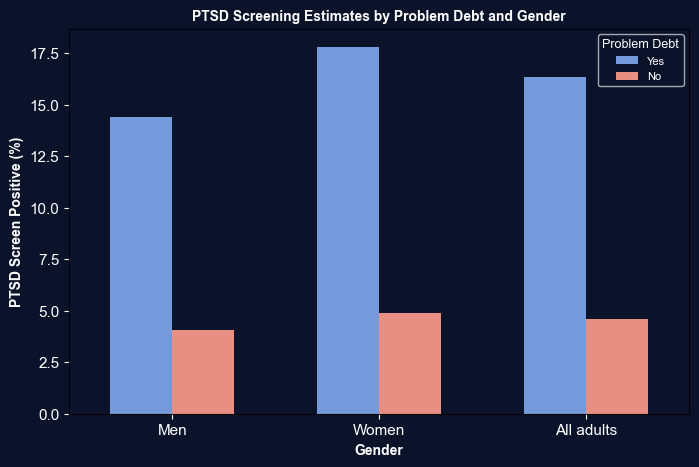

In [26]:
# Set the font used throughout the chart
plt.rcParams["font.family"] = "Arial"

# Create the figure and plotting area
fig, ax = plt.subplots(figsize=(8, 5))

# Set a dark navy background
fig.patch.set_facecolor("#0B132B")
ax.set_facecolor("#0B132B")

# Create the grouped bar chart
sns.barplot(
    data=debt_ptsd,
    x="gender",
    y="percentage",
    hue="problem_debt",
    palette=["cornflowerblue", "salmon"],
    width=0.6,
    errorbar=None,
    ax=ax
)

# Add title and labels using light text for the dark background
ax.set_title(
    "PTSD Screening Estimates by Problem Debt and Gender",
    fontsize=10,
    fontweight="bold",
    color="white"
)

ax.set_xlabel("Gender", fontsize=10, fontweight="bold", color="white")
ax.set_ylabel("PTSD Screen Positive (%)", fontsize=10, fontweight="bold", color="white")

# Make the axis values visible on the dark background
ax.tick_params(axis="x", colors="white", labelsize=11)
ax.tick_params(axis="y", colors="white", labelsize=11)

# Make the legend match the dark theme
legend = ax.legend(
    title="Problem Debt",
    fontsize=8,
    title_fontsize=9
)

legend.get_frame().set_facecolor("#0B132B")

plt.setp(legend.get_texts(), color="white")
plt.setp(legend.get_title(), color="white")

plt.show()


Algorithm note - Visualising PTSD screening by problem debt and gender

We use Seaborn `barplot()` and Matplotlib to create a grouped bar chart comparing PTSD screening percentages across gender and problem-debt groups.

- `plt.rcParams["font.family"]` sets Arial as the chart font.
- `plt.subplots(figsize=(8, 5))` creates the figure and plotting area.
- `fig.patch.set_facecolor()` sets the outer background to dark navy.
- `ax.set_facecolor()` sets the plotting background to dark navy.
- `data=debt_ptsd` selects the PTSD screening dataset.
- `x="gender"` places gender groups on the horizontal axis.
- `y="percentage"` displays PTSD screening percentages.
- `hue="problem_debt"` separates Yes and No groups using different colours.
- `palette` assigns cornflower blue and salmon to the two groups.
- `width=0.6` controls bar width.
- `errorbar=None` removes uncertainty bars.
- `ax=ax` draws the chart on our selected plotting area.

We then customise the chart using `set_title()`, `set_xlabel()`, and `set_ylabel()`. The `tick_params()` method changes axis text colours, while `legend()` and `plt.setp()` adjust the legend to match the dark background.


In [27]:
# Keep only the trauma-experienced estimates
# This lets us compare trauma prevalence for adults
# with and without problem debt
debt_trauma = debt_analysis[
    debt_analysis["measure"] == "Trauma experienced"
].copy()

# Display the main columns needed for EDA
debt_trauma[
    ["gender", "problem_debt", "percentage", "sample_size"]
]

,gender,problem_debt,percentage,sample_size
0,Men,Yes,48.115202,171.0
2,Women,Yes,52.225426,336.0
4,All adults,Yes,50.470283,507.0
6,Men,No,30.587807,2372.0
8,Women,No,35.797899,3142.0
10,All adults,No,33.422477,5523.0



Algorithm note - Filtering trauma-experienced estimates

We use Boolean filtering to keep only trauma-experienced observations from `debt_analysis`. This allows us to compare trauma prevalence between adults with and without problem debt across gender groups.

- `debt_analysis["measure"]` accesses the measure column.
- `== "Trauma experienced"` checks which rows match the selected measure.
- `debt_analysis[...]` keeps only matching observations.
- `.copy()` creates an independent DataFrame.
- `debt_trauma` stores the filtered trauma observations.

Observations:

- All adults: 50.47% with debt vs 33.42% without debt.
- Men: 48.12% with debt vs 30.59% without debt.
- Women: 52.23% with debt vs 35.80% without debt.
- Trauma prevalence is higher among adults with problem debt across all gender groups.
- Women show higher trauma-experienced percentages than men in both debt categories.


In [28]:
# Reshape the data so Yes and No become separate columns
# This makes the two problem-debt groups easy to compare
debt_trauma_comparison = debt_trauma.pivot(
    index="gender",
    columns="problem_debt",
    values="percentage"
)

# Calculate the percentage-point difference
# Positive values mean trauma prevalence is higher
# among adults with problem debt
debt_trauma_comparison["difference"] = (
    debt_trauma_comparison["Yes"]
    - debt_trauma_comparison["No"]
)

# Round the results for easier interpretation
debt_trauma_comparison = debt_trauma_comparison.round(2)

debt_trauma_comparison

problem_debt,No,Yes,difference
gender,,,
All adults,33.422477,50.470283,17.047806
Men,30.587807,48.115202,17.527395
Women,35.797899,52.225426,16.427527



Algorithm note - Reshaping trauma estimates and calculating percentage-point differences

We use `.pivot()` to reshape trauma-experienced estimates from long to wide format, then calculate the percentage-point difference between adults with and without problem debt for each gender group.

- `.pivot()` reorganises the data into a comparison table.
- `index="gender"` uses Men, Women, and All adults as row labels.
- `columns="problem_debt"` creates separate Yes and No columns.
- `values="percentage"` fills the columns with trauma-experienced percentages.
- `["Yes"] - ["No"]` calculates the percentage-point difference for each gender.
- `["difference"]` stores the calculated differences in a new column.
- `.round(2)` rounds all numerical values to two decimal places.

Observations:

- All adults: 50.47% with debt vs 33.42% without debt = 17.05 percentage points.
- Men: 48.12% with debt vs 30.59% without debt = 17.53 percentage points.
- Women: 52.23% with debt vs 35.80% without debt = 16.43 percentage points.
- All three groups show positive differences, indicating higher trauma prevalence among adults with problem debt.
- Men show a slightly larger percentage-point difference than women.

Result: `debt_trauma_comparison` contains the Yes, No, and difference columns for each gender. 


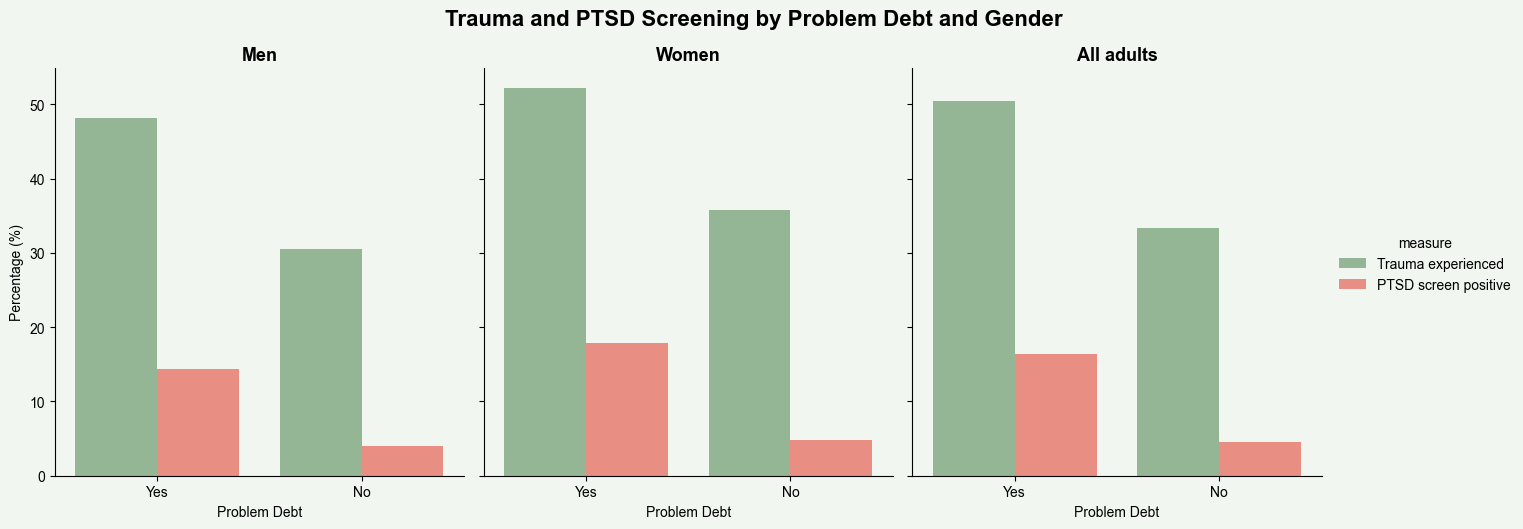

In [29]:
# 1. Set the overall chart style
plt.rcParams["font.family"] = "Arial"

# 2. Draw the chart
g = sns.catplot(
    data=debt_analysis,
    x="problem_debt",
    y="percentage",
    hue="measure",
    col="gender",
    kind="bar",
    palette=["darkseagreen", "salmon"],
    height=5,
    aspect=0.9,
    errorbar=None
)

# 3. Add labels
g.set_axis_labels(
    "Problem Debt",
    "Percentage (%)"
)

# 4. Add a title to each gender panel
g.set_titles(
    "{col_name}",
    size=13,
    weight="bold"
)

# 5. Add the main chart title
g.figure.suptitle(
    "Trauma and PTSD Screening by Problem Debt and Gender",
    fontsize=16,
    fontweight="bold",
    y=1.05
)

# 6. Give the chart a soft pale-green background
g.figure.patch.set_facecolor("#F1F6F1")

for ax in g.axes.flat:
    ax.set_facecolor("#F1F6F1")

# 7. Display the finished chart
plt.show()


Algorithm note - Visualising trauma and PTSD screening by problem debt and gender

We use Seaborn `catplot()` to create separate grouped bar charts for Men, Women, and All adults. This allows us to compare trauma-experienced and PTSD screen-positive percentages between people with and without problem debt.

- `plt.rcParams["font.family"]` sets Arial as the chart font.
- `data=debt_analysis` selects the combined trauma and PTSD dataset.
- `x="problem_debt"` places Yes and No categories on the horizontal axis.
- `y="percentage"` displays the percentage estimates.
- `hue="measure"` separates Trauma experienced and PTSD screen positive using different colours.
- `col="gender"` creates a separate chart panel for each gender group.
- `kind="bar"` creates grouped bar charts.
- `palette` assigns darkseagreen and salmon to the two measures.
- `height=5` and `aspect=0.9` control the size and proportions of each panel.
- `errorbar=None` removes uncertainty bars.

We then customise the chart using `set_axis_labels()` for axis labels, `set_titles()` for gender headings, and `suptitle()` for the overall title. The `set_facecolor()` methods apply a pale-green background to the figure and plotting areas.

Observations:

- Trauma-experienced percentages are higher than PTSD screen-positive percentages across all groups.
- Adults with problem debt show higher trauma and PTSD screening percentages than those without problem debt.
- Women generally show higher percentages than men for both measures.
- The All adults panel provides an overall comparison without separating gender.

Why? To examine two mental-health-related measures simultaneously and identify patterns across problem-debt status and gender.


Interpretation of Visualization

The chart compares trauma-experienced and PTSD screen-positive percentages among adults with and without problem debt, separated into Men, Women, and All adults.

Observations:

- Men: PTSD screening is approximately 14.39% among those with problem debt, compared with 4.06% among those without. Trauma experience is also higher (48.12% vs 30.59%).
- Women: PTSD screening is approximately 17.81% among those with problem debt, compared with 4.87% among those without. Trauma experience follows the same pattern (52.23% vs 35.80%).
- All adults: PTSD screening is 16.36% among adults with problem debt, compared with 4.59% among those without, a difference of 11.78 percentage points.
- Trauma experience is consistently more common than PTSD screen positivity across all groups.
- Women have slightly higher trauma and PTSD screening percentages than men in both problem-debt categories.
- The difference between debt groups is particularly noticeable for PTSD screening, with prevalence approximately 3–4 times higher among adults with problem debt.

Key insight:

Problem debt is associated with substantially higher trauma experience and PTSD screen-positive percentages across both genders. The pattern is consistent for Men, Women, and All adults.